# **Clasificador Bayesiano**

## **Librerías**

In [18]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

In [19]:
from sklearn.metrics import *
from sklearn.ensemble import *
from sklearn.pipeline import *
from sklearn.preprocessing import *
from sklearn.model_selection import *
from sklearn.feature_selection import *
from sklearn.naive_bayes import CategoricalNB

## **Data**

In [20]:
df = pd.read_excel("../data/processed/df_to_model_frenel_15102025.xlsx")
df.head()

,target_tfg,pais_encuesta,grupo_origen,pais_nacimiento,edad,genero,grupo_etnico,nivel_escolaridad,regimen_salud,ocupacion,...,hacinamiento_hogar,hogar_migrantes,grupo_origen_ingles,ocupacion_agricola,imc,clasificacion_imc,grupo_edad,clasificacion_tfg,clasificacion_pa,creatinina_elevada
0,0,COLOMBIA,AFRODESCENDIENTE,COLOMBIA,49,Femenino,AFRODESCENDIENTE,Primaria,Asegurador público,Comerciante,...,NO,NO,AFRODESCENDANT,NO,32.326531,Obesidad,41-50,Ligera (60-89),Hipertensión grado 2 (moderada),False
1,1,COLOMBIA,AFRODESCENDIENTE,COLOMBIA,83,Femenino,AFRODESCENDIENTE,No escolarizado,Asegurador privado,Desempleado,...,NO,NO,AFRODESCENDANT,NO,22.206331,Normal,60+,Leve Moderada (45-59),Normal-alta,True
2,0,COLOMBIA,AFRODESCENDIENTE,COLOMBIA,70,Femenino,AFRODESCENDIENTE,No escolarizado,Asegurador público,Comerciante,...,SI,NO,AFRODESCENDANT,NO,20.820940,Normal,60+,Ligera (60-89),Hipertensión grado 2 (moderada),False
3,0,COLOMBIA,AFRODESCENDIENTE,COLOMBIA,25,Femenino,AFRODESCENDIENTE,Técnica,Asegurador público,Comerciante,...,NO,NO,AFRODESCENDANT,NO,23.738662,Normal,18-30,Ligera (60-89),Normal,True
4,1,COLOMBIA,AFRODESCENDIENTE,COLOMBIA,64,Femenino,AFRODESCENDIENTE,Primaria,Asegurador público,Desempleado,...,NO,NO,AFRODESCENDANT,NO,19.257029,Normal,60+,Leve Moderada (45-59),Normal,True


## **Preprocesamiento**

### **Selección de Variables**

In [21]:
columnas_a_excluir = ['pais_encuesta', 'grupo_origen', 'pais_nacimiento','edad', 'georeferenciacion', 'presion_arterial_sistolica', 
                      'presion_arterial_diastolica', 'creatinina', 'peso', 'talla', 'grupo_origen_ingles', 'imc', 'clasificacion_tfg',
                      'tasa_filtracion_glomerular', 'ocupacion', 'creatinina_elevada']
df.drop(columns=columnas_a_excluir, inplace=True)

### **Codificación Variables Categóricas**

In [22]:
df_col = df.drop(columns=['target_tfg'])
cat_cols = df_col.select_dtypes(include=['object', 'bool']).columns
num_cols = df_col.select_dtypes(include=['int64', 'float64']).columns
#print("Categorical columns: \n", cat_cols)
#print("Numerical columns: \n", num_cols)

In [23]:
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [24]:
df_modelo = df_encoded.copy()

## **Modelo**

### **Conjuntos de `Train` y `Test`**

In [25]:
X = df_modelo.drop(columns=['target_tfg'])
y = df_modelo['target_tfg']

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=11, stratify=y)
print("Train set size:", X_train.shape)
print("Test set size:", X_test.shape)

Train set size: (3567, 68)
Test set size: (1189, 68)


In [27]:
# Pipeline con Categorical Naive Bayes
pipeline = make_pipeline(SelectKBest(k=25), CategoricalNB())

# Hiperparámetros a ajustar
param_grid = {
    'categoricalnb__alpha': [0.01, 0.1, 0.5, 1.0, 2.0],  # suavizado de Laplace
    'categoricalnb__fit_prior': [True, False]
}

# Grid Search optimizando el recall
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='recall')

# Entrenamiento
grid_search.fit(X_train, y_train)

# Resultados
print("Mejores parámetros:", grid_search.best_params_)
print("Mejor Recall en Train:", grid_search.best_score_)
print("Mejor Recall en Test:", recall_score(y_test, grid_search.predict(X_test)))

Mejores parámetros: {'categoricalnb__alpha': 0.01, 'categoricalnb__fit_prior': False}
Mejor Recall en Train: 0.6292697804112931
Mejor Recall en Test: 0.5573122529644269


### **Métricas y Resultados**

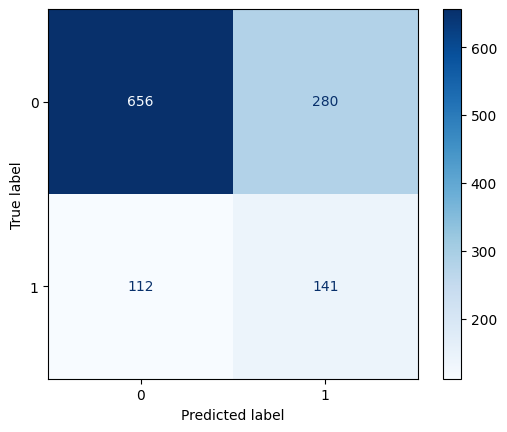

In [28]:
y_pred = grid_search.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot(cmap='Blues')

In [29]:
# Predicciones en TRAIN
y_train_pred = grid_search.predict(X_train)
y_train_prob = grid_search.predict_proba(X_train)[:, 1]

# Predicciones en TEST
y_test_pred = grid_search.predict(X_test)
y_test_prob = grid_search.predict_proba(X_test)[:, 1]

# Crear tabla comparativa
resultados = {
    'Dataset': ['Train', 'Test'],
    'Precision': [
        precision_score(y_train, y_train_pred),
        precision_score(y_test, y_test_pred)
    ],
    'Recall': [
        recall_score(y_train, y_train_pred),
        recall_score(y_test, y_test_pred)
    ],
    'F1 Score': [
        f1_score(y_train, y_train_pred),
        f1_score(y_test, y_test_pred)
    ],
    'ROC AUC': [
        roc_auc_score(y_train, y_train_prob),
        roc_auc_score(y_test, y_test_prob)
    ]
}

metricas_tree = pd.DataFrame(resultados)
metricas_tree


,Dataset,Precision,Recall,F1 Score,ROC AUC
0,Train,0.371055,0.635884,0.468644,0.735985
1,Test,0.334917,0.557312,0.418398,0.711528


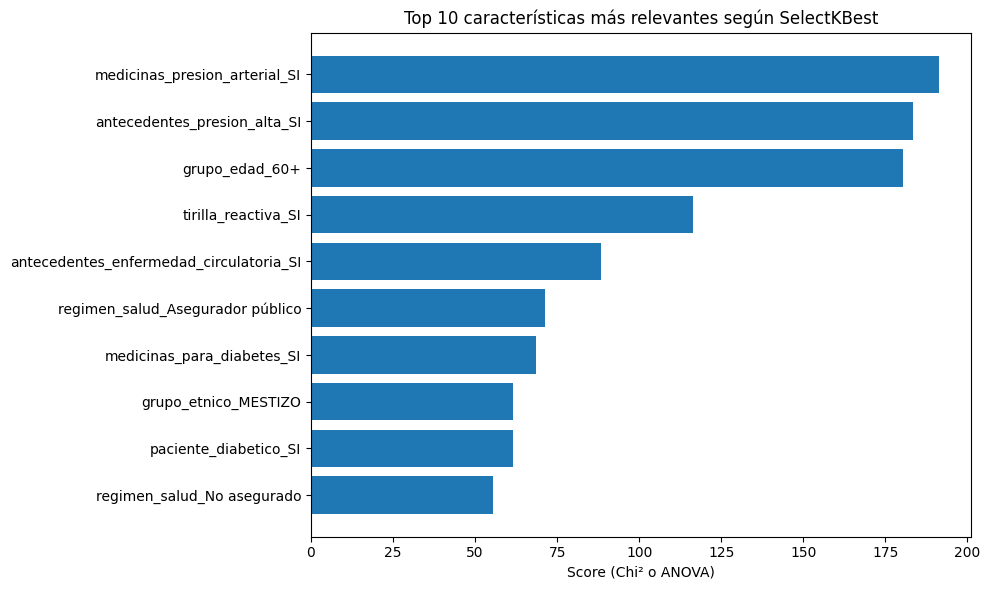

In [30]:
# Obtener las puntuaciones de SelectKBest
scores = selector.scores_
selected_features = feature_names[selector.get_support()]

# Ordenar las variables seleccionadas por score descendente
sorted_indices = np.argsort(scores[selector.get_support()])[::-1]

# Elegir las top N
top_n = 10
top_indices = sorted_indices[:top_n]
top_scores = scores[selector.get_support()][top_indices]
top_features = selected_features[top_indices]

# Graficar
plt.figure(figsize=(10, 6))
plt.barh(range(top_n), top_scores[::-1], align='center')
plt.yticks(range(top_n), top_features[::-1])
plt.xlabel('Score (Chi² o ANOVA)')
plt.title(f'Top {top_n} características más relevantes según SelectKBest')
plt.tight_layout()
plt.show()
